In [11]:




import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [12]:
import glob

csv_files = glob.glob('/instructorEffective.csv')

if not csv_files:
    raise FileNotFoundError(
        "No CSV file found. Upload the assignment CSV to the notebook/Colab session."
    )

DATA_PATH = csv_files[0]
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Loaded: /instructorEffective.csv
Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique identifiers:")
print("Batches:", df["batch_id"].nunique())
print("Instructors:", df["instructor_id"].nunique())
print("Courses:", df["course_id"].nunique())

display(df.describe().T)


Rows: 2000
Columns: 12

Column types:


,0
batch_id,object
instructor_id,object
course_id,object
completion_rate,float64
avg_score_improvement,float64
avg_quiz_score,float64
dropout_rate,float64
avg_watch_time,float64
assignment_submission_rate,float64
forum_activity_rate,float64



Missing values:


,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0



Duplicate rows: 0

Unique identifiers:
Batches: 2000
Instructors: 120
Courses: 25


,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


EDA

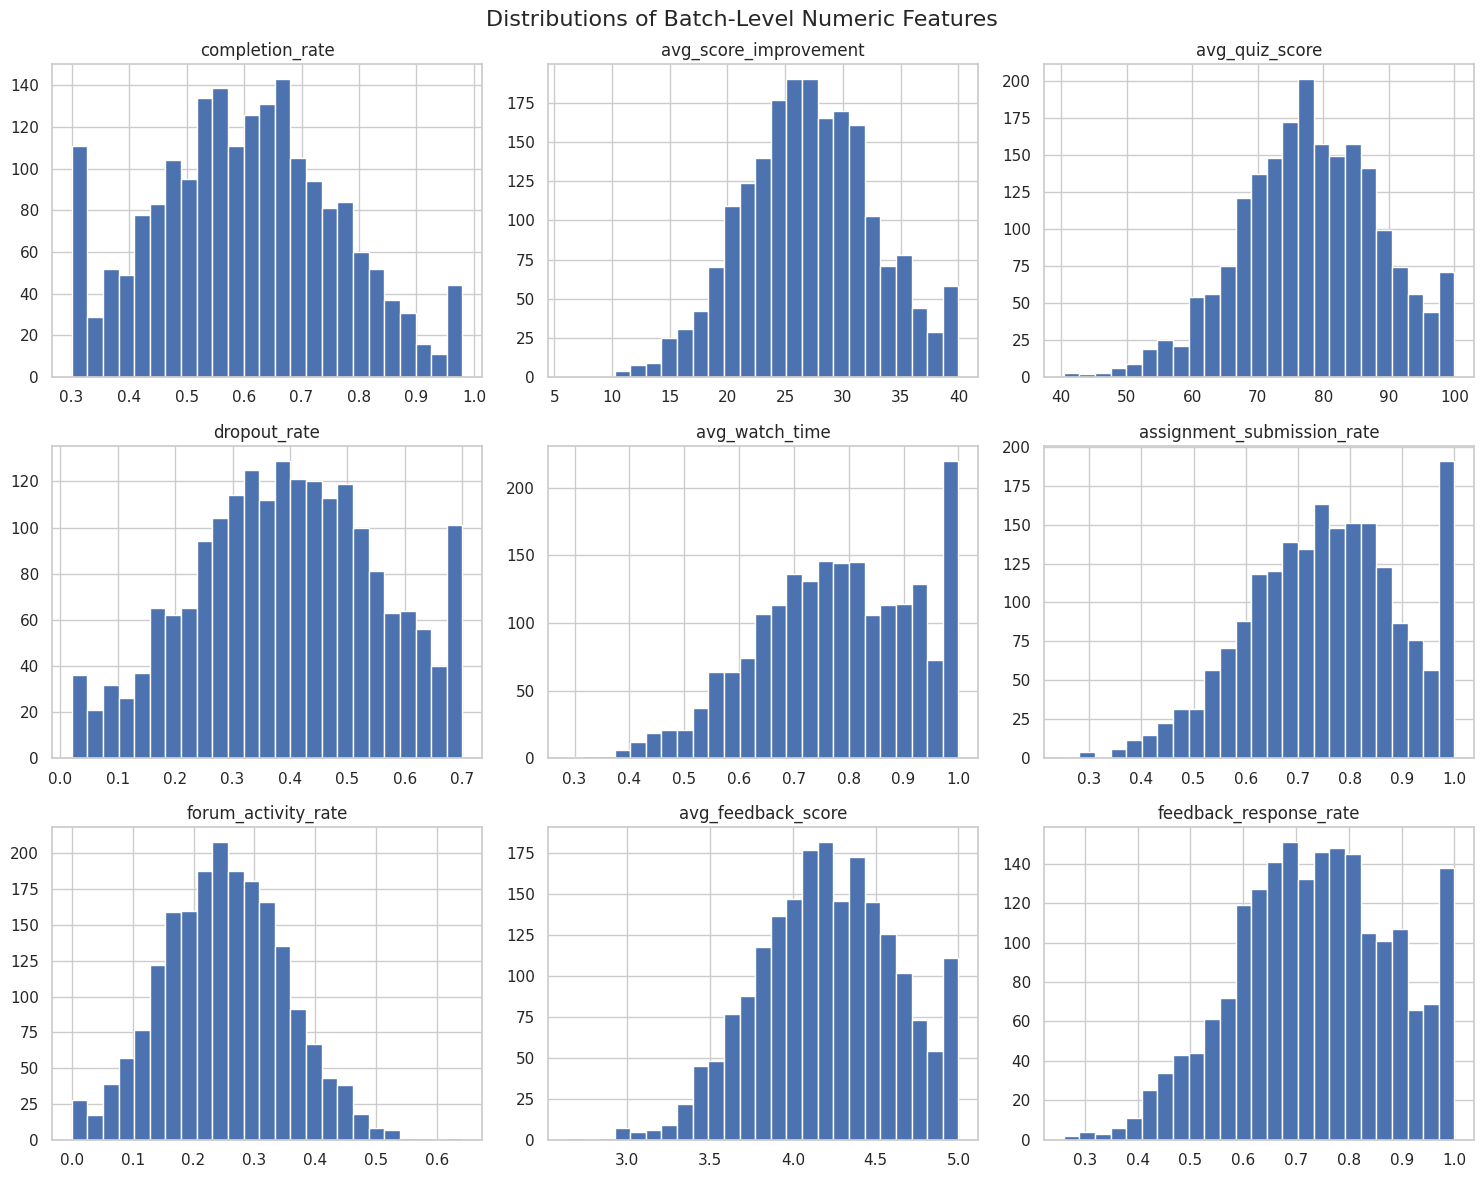

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(figsize=(15, 12), bins=25)
plt.suptitle("Distributions of Batch-Level Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()


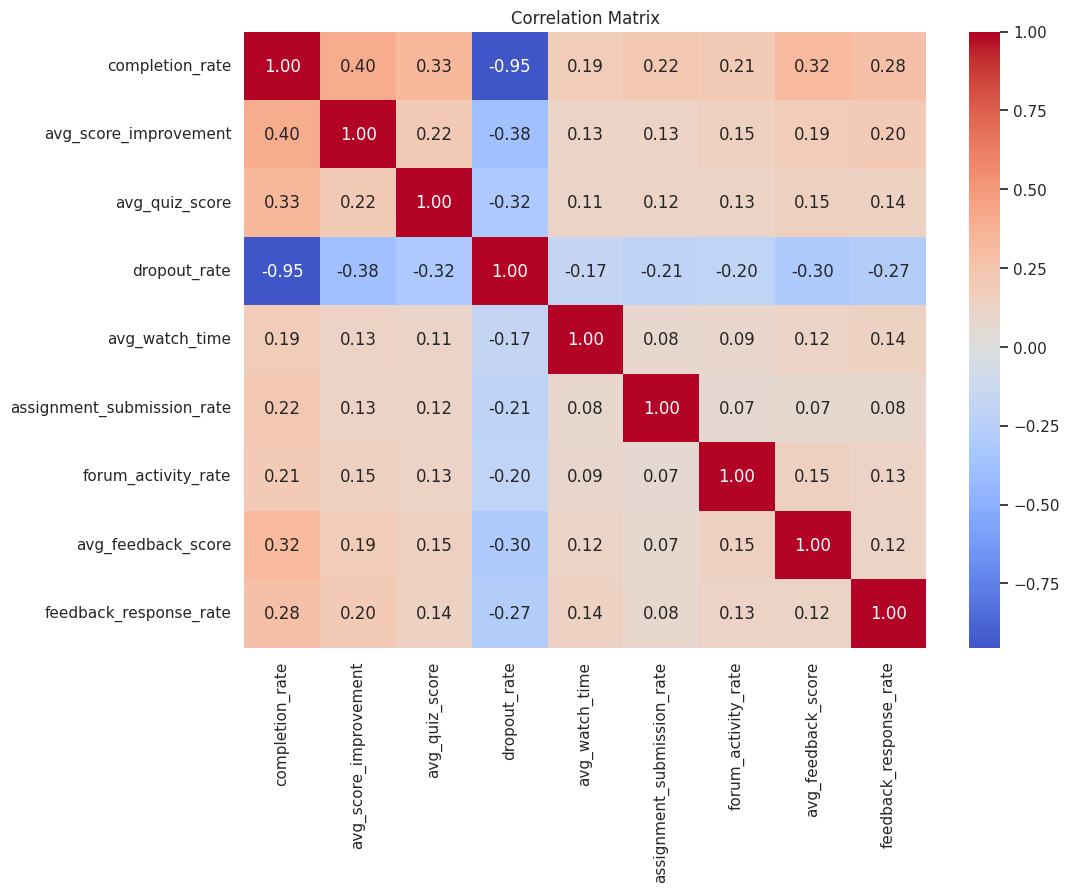

In [15]:
plt.figure(figsize=(11, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


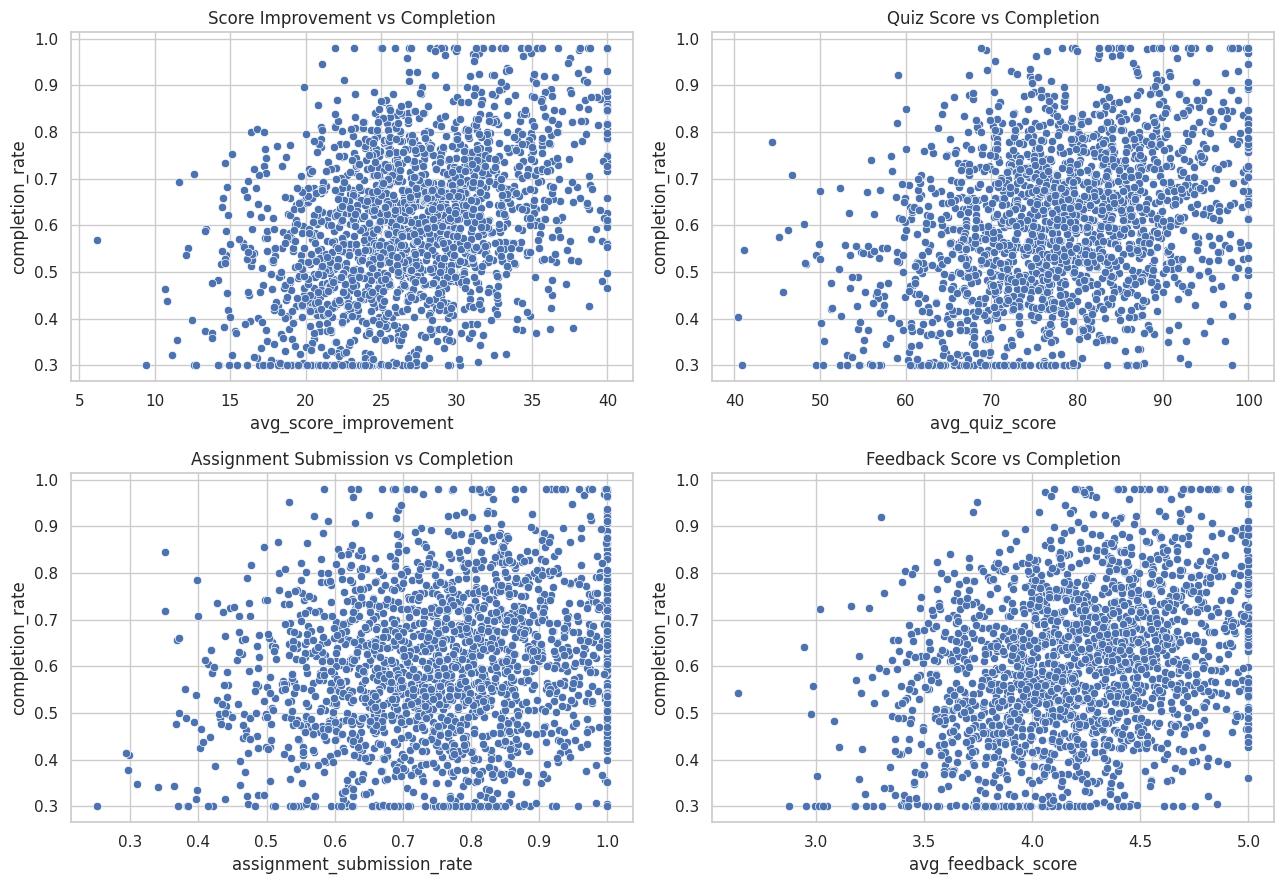

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.scatterplot(data=df, x="avg_score_improvement", y="completion_rate", ax=axes[0, 0])
axes[0, 0].set_title("Score Improvement vs Completion")

sns.scatterplot(data=df, x="avg_quiz_score", y="completion_rate", ax=axes[0, 1])
axes[0, 1].set_title("Quiz Score vs Completion")

sns.scatterplot(data=df, x="assignment_submission_rate", y="completion_rate", ax=axes[1, 0])
axes[1, 0].set_title("Assignment Submission vs Completion")

sns.scatterplot(data=df, x="avg_feedback_score", y="completion_rate", ax=axes[1, 1])
axes[1, 1].set_title("Feedback Score vs Completion")

plt.tight_layout()
plt.show()


Instructor Batch Distribution


count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
Name: count, dtype: float64


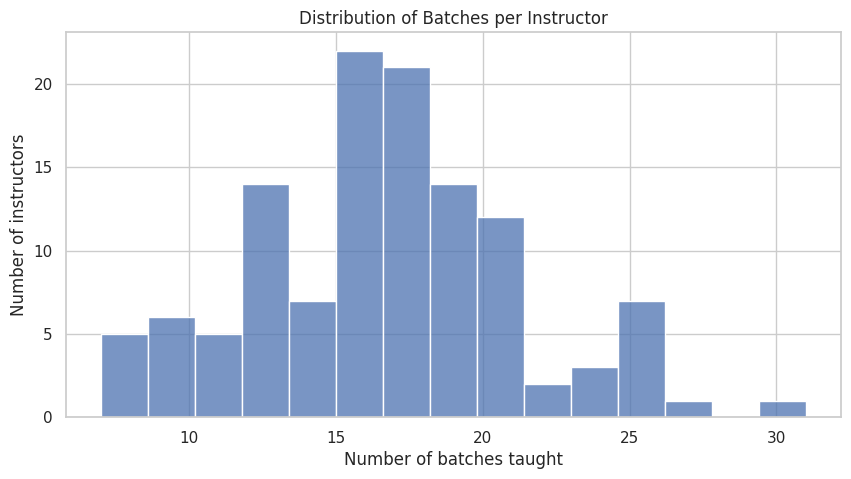

In [17]:
batch_counts = df["instructor_id"].value_counts()

print(batch_counts.describe())

plt.figure(figsize=(10, 5))
sns.histplot(batch_counts, bins=15)
plt.xlabel("Number of batches taught")
plt.ylabel("Number of instructors")
plt.title("Distribution of Batches per Instructor")
plt.show()


**Define Instructor Effectiveness**


In [18]:
# Normalize metrics with different scales.
scaler = MinMaxScaler()

score_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_feedback_score"
]

scaled = pd.DataFrame(
    scaler.fit_transform(df[score_cols]),
    columns=score_cols,
    index=df.index
)

scaled["retention_score"] = 1 - scaled["dropout_rate"]
scaled["feedback_score_norm"] = scaled["avg_feedback_score"]

# Batch-level outcome component
df["outcome_score"] = (
    0.35 * scaled["completion_rate"]
    + 0.15 * scaled["retention_score"]
    + 0.30 * scaled["avg_score_improvement"]
    + 0.20 * scaled["avg_quiz_score"]
)

# Final batch-level effectiveness score
df["effectiveness_score"] = (
    0.80 * df["outcome_score"]
    + 0.20 * scaled["feedback_score_norm"]
)

df[[
    "batch_id", "instructor_id", "outcome_score",
    "effectiveness_score"
]].head()


,batch_id,instructor_id,outcome_score,effectiveness_score
0,B_1861,I_044,0.194359,0.250933
1,B_0354,I_119,0.516539,0.613231
2,B_1334,I_050,0.219452,0.249921
3,B_0906,I_024,0.613442,0.623602
4,B_1290,I_001,0.575360,0.611665


**Aggregate Batch Level Data to Instructor Level**

In [19]:
instructor_df = df.groupby("instructor_id").agg(
    effectiveness_score=("effectiveness_score", "mean"),

    completion_mean=("completion_rate", "mean"),
    completion_std=("completion_rate", "std"),

    dropout_mean=("dropout_rate", "mean"),
    dropout_std=("dropout_rate", "std"),

    score_improvement_mean=("avg_score_improvement", "mean"),
    score_improvement_std=("avg_score_improvement", "std"),

    quiz_mean=("avg_quiz_score", "mean"),
    quiz_std=("avg_quiz_score", "std"),

    feedback_mean=("avg_feedback_score", "mean"),
    feedback_std=("avg_feedback_score", "std"),

    watch_mean=("avg_watch_time", "mean"),
    watch_std=("avg_watch_time", "std"),

    assignment_mean=("assignment_submission_rate", "mean"),
    assignment_std=("assignment_submission_rate", "std"),

    forum_mean=("forum_activity_rate", "mean"),
    forum_std=("forum_activity_rate", "std"),

    feedback_response_mean=("feedback_response_rate", "mean"),
    feedback_response_std=("feedback_response_rate", "std"),

    batch_count=("batch_id", "nunique"),
    course_count=("course_id", "nunique")
).reset_index()

# An instructor with one batch has undefined standard deviation.
std_cols = [c for c in instructor_df.columns if c.endswith("_std")]
instructor_df[std_cols] = instructor_df[std_cols].fillna(0)

instructor_df.head()


,instructor_id,effectiveness_score,completion_mean,completion_std,dropout_mean,dropout_std,score_improvement_mean,score_improvement_std,quiz_mean,quiz_std,feedback_mean,feedback_std,watch_mean,watch_std,assignment_mean,assignment_std,forum_mean,forum_std,feedback_response_mean,feedback_response_std,batch_count,course_count
0,I_001,0.523247,0.543887,0.084611,0.470593,0.087671,26.641462,6.074232,78.900194,8.878089,4.217743,0.388802,0.766513,0.131532,0.726893,0.145189,0.240551,0.094695,0.694858,0.166455,25,16
1,I_002,0.682892,0.730874,0.103691,0.247194,0.098811,30.166242,3.939007,81.737198,9.843168,4.343002,0.440235,0.837393,0.112701,0.774394,0.141096,0.289610,0.088573,0.784338,0.114460,20,10
2,I_003,0.707886,0.768447,0.120452,0.234828,0.115966,29.977813,5.074705,81.590928,11.064673,4.450034,0.386108,0.818441,0.158280,0.779606,0.121712,0.296224,0.082414,0.812132,0.141805,18,14
3,I_004,0.432786,0.458328,0.067596,0.547261,0.083598,22.912021,4.826162,77.680317,12.485520,4.076410,0.400982,0.793130,0.126603,0.758317,0.135790,0.226259,0.093217,0.721460,0.133622,17,10
4,I_005,0.770117,0.859747,0.090287,0.145733,0.097634,32.588652,4.621194,85.828159,7.228742,4.202516,0.304174,0.847026,0.108567,0.876942,0.102360,0.333519,0.105278,0.784197,0.127054,19,13


**Convert Effectiveness Score into Tiers**

,count
effectiveness_tier,
Low,40
Medium,40
High,40


,min,mean,max
effectiveness_tier,,,
Low,0.270264,0.426496,0.519286
Medium,0.521505,0.561226,0.604899
High,0.605225,0.691948,0.875825


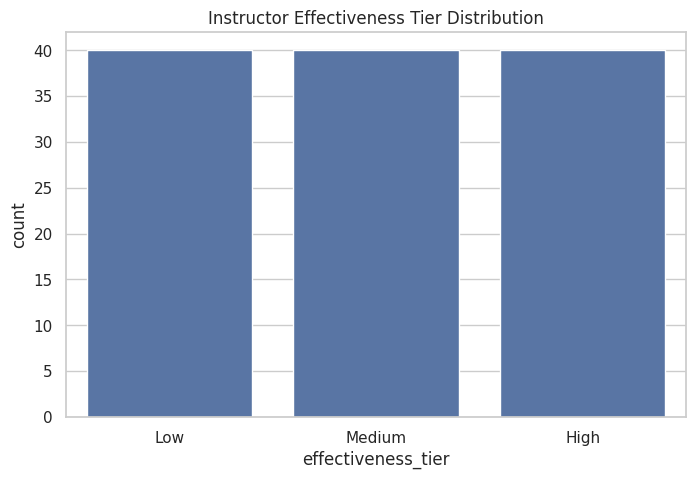

In [20]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

display(instructor_df["effectiveness_tier"].value_counts())

tier_summary = instructor_df.groupby(
    "effectiveness_tier", observed=True
)["effectiveness_score"].agg(["min", "mean", "max"])

display(tier_summary)

plt.figure(figsize=(8, 5))
sns.countplot(data=instructor_df, x="effectiveness_tier")
plt.title("Instructor Effectiveness Tier Distribution")
plt.show()


Instructor Level Effectiveness Visualisation

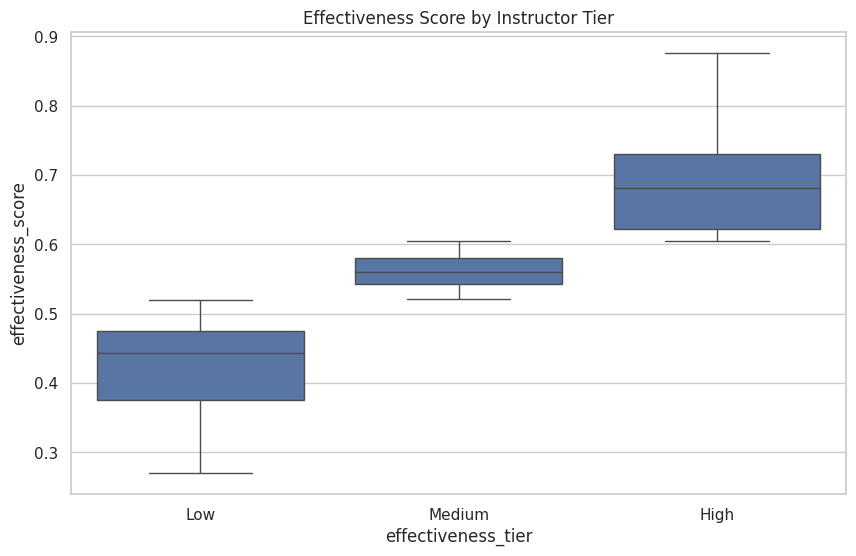

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=instructor_df,
    x="effectiveness_tier",
    y="effectiveness_score",
    order=["Low", "Medium", "High"]
)
plt.title("Effectiveness Score by Instructor Tier")
plt.show()


**ML Problem Definiton**

In [22]:
features = [
    "watch_mean",
    "watch_std",
    "assignment_mean",
    "assignment_std",
    "forum_mean",
    "forum_std",
    "feedback_response_mean",
    "batch_count",
    "course_count"
]

X = instructor_df[features].copy()
y = instructor_df["effectiveness_tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("\nTraining class distribution:")
print(y_train.value_counts())


Training rows: 90
Testing rows: 30

Training class distribution:
effectiveness_tier
Low       30
Medium    30
High      30
Name: count, dtype: int64


**Logistic Regression Model **

In [23]:
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, log_pred), 3))
print("Macro F1:", round(f1_score(y_test, log_pred, average="macro"), 3))
print("\nClassification Report:")
print(classification_report(y_test, log_pred))


Accuracy: 0.5
Macro F1: 0.459

Classification Report:
              precision    recall  f1-score   support

        High       0.58      0.70      0.64        10
         Low       0.54      0.70      0.61        10
      Medium       0.20      0.10      0.13        10

    accuracy                           0.50        30
   macro avg       0.44      0.50      0.46        30
weighted avg       0.44      0.50      0.46        30



**Random Forest Model**

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Macro F1:", round(f1_score(y_test, rf_pred, average="macro"), 3))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Accuracy: 0.633
Macro F1: 0.642

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.70      0.74        10
         Low       0.75      0.60      0.67        10
      Medium       0.46      0.60      0.52        10

    accuracy                           0.63        30
   macro avg       0.66      0.63      0.64        30
weighted avg       0.66      0.63      0.64        30



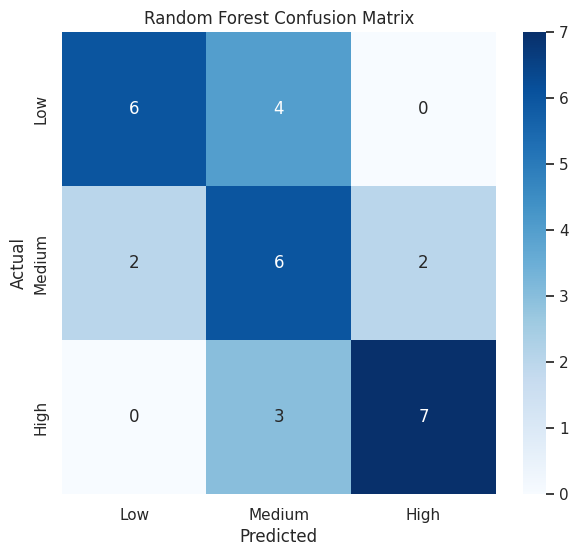

In [25]:
cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


Cross Validation

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Fold Macro-F1 scores:", np.round(cv_scores, 3))
print("Mean Macro-F1:", round(cv_scores.mean(), 3))
print("Std Macro-F1:", round(cv_scores.std(), 3))


Fold Macro-F1 scores: [0.673 0.833 0.577 0.543 0.574]
Mean Macro-F1: 0.64
Std Macro-F1: 0.106


Feature Importance

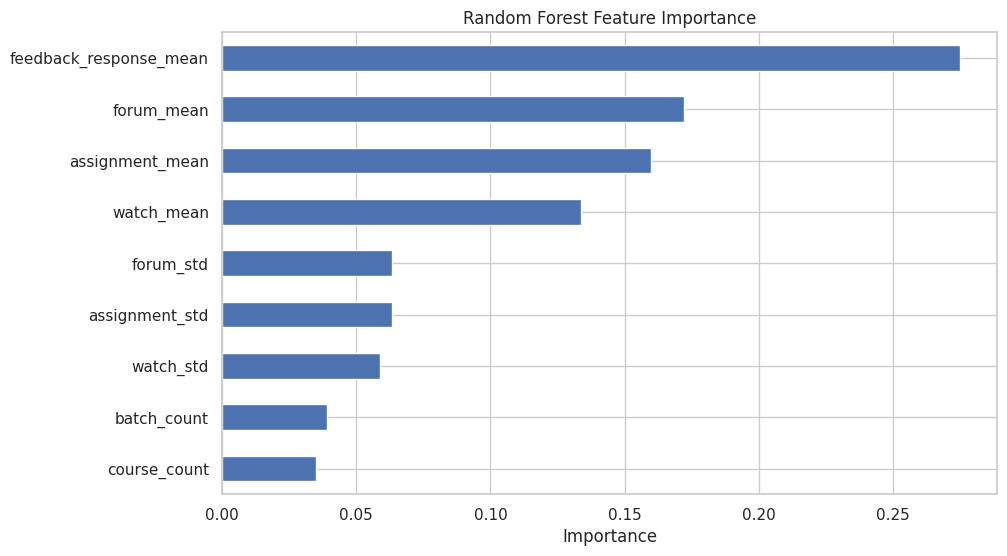

,importance
feedback_response_mean,0.275097
forum_mean,0.172081
assignment_mean,0.159732
watch_mean,0.133676
forum_std,0.063369
assignment_std,0.063341
watch_std,0.058729
batch_count,0.039057
course_count,0.034918


In [27]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

display(importance.sort_values(ascending=False).to_frame("importance"))


**Instructor Course Analysis**

In [28]:
df["scaled_outcome"] = df["outcome_score"]

instructor_course = (
    df.groupby(["instructor_id", "course_id"])
      .agg(
          batches=("batch_id", "nunique"),
          mean_effectiveness=("effectiveness_score", "mean"),
          mean_completion=("completion_rate", "mean"),
          mean_quiz=("avg_quiz_score", "mean")
      )
      .reset_index()
)

display(instructor_course.head(10))


,instructor_id,course_id,batches,mean_effectiveness,mean_completion,mean_quiz
0,I_001,C_01,2,0.563422,0.561168,82.933093
1,I_001,C_03,1,0.474941,0.513849,76.333152
2,I_001,C_04,1,0.459020,0.425241,70.306925
3,I_001,C_05,1,0.551370,0.474798,90.405124
4,I_001,C_08,6,0.568425,0.561681,81.468206
5,I_001,C_09,1,0.542407,0.587010,78.961710
6,I_001,C_10,1,0.615240,0.543123,90.501148
7,I_001,C_11,1,0.383520,0.436609,67.561816
8,I_001,C_12,2,0.531544,0.594207,79.161656
9,I_001,C_14,2,0.498826,0.489719,71.564629


** Mandatory Question **

## Q1. What were the most important features affecting instructor effectiveness? Why?


Instead of assuming the answer beforehand, the analysis should start with the model’s feature importance output. In this dataset, the primary predictive signals are from engageme features as the target is defined from learning outcomes and feedback whereas engagement is reserved for prediction.


Learner engagement is important because instructors who consistently encourage learners to view lessons, submit assignments, participate in discussion forums and respond to feedback may be linked to better learner outcomes.


However, these relationships should be taken as associations rather than evidence of causation.Q2. What variables may be confounded or misinterpreted?


Some variables can be deceptive:

- **Completion rate:** a high value may mean an easy course, not necessarily good instruction.
 **Dropout rate: **strongly linked to completion


## Q2. Which variables are possibly spurious or confounding?


There are several variables that can be misleading:

- **Completion rate:** A high value may suggest the course was easy, not the instructor.
- **Dropout rate:** strongly correlated with completion, so counting both separately can double count similar evidence.
- **Quiz performance:** can indicate the difficulty of the assessment and learner readiness.
- **Feedback score:** Can be affected by the instructor’s popularity, the severity of grading, or the bias of the response.
- **Watch time:** A longer watch time doesn’t necessarily mean a good thing; watch time can be long or confusing videos.
- **Forum activity:** low activity may be a reflection of learner preferences rather than poor teaching.
- **Course ID:** the challenge and number of students can differ dramatically from course to course.


## Q3. Where in the real world could this model fail?


When the model can be wrong:


1. The new instructor has very few classes.
2. The learner population is different for a new course.
3. Course difficulty changes through time.
4. The platform shifts its assessment or engagement model.
5. Feedback response rates are biased toward learners who are unusually satisfied or dissatisfied.
6. Averages at the batch level mask large differences between the individual learners.
7. The training data is not representative of future cohorts .
8. The model is used outside the distribution it was trained on.

## Q4. What additional information would enhance the analysis?


The most useful additions would be . . .

- learner-level pre-test and post-test scores- student attendance
- number of students per batch
- difficulty of course
- prior knowledge of learner
- instructor's experience and tenure
- live sessions count
- response time to learner queries
- difficulty level of assignments and tests
- Drop out rate at learner level
history of instructor traininghistorical performance
- description of cohort

## Q5. Is this model the one to use for evaluating instructor performance?

**Not as a stand-alone performance appraisal system.**


It is to be used as a decision support tool. Learner preparedness, course difficulty, assessment design, cohort composition, and platform behaviour all can impact instructor outcomes. Therefore, it could be unfair to penalise an instructor automatically based on this model alone.


A safer workflow would be to:

**Model signal Human check Context check Support/intervention Follow-up measurement**


The model should be used to bring to surface instructors or batches for further review, not for making irreversible decisions regarding employment or compensation.